# Customer Churn analysis and prediction for a telecom company

## Overview
This project showcases likelihoodness of a customer churning based on analysis and SHapley Additive exPlanations (SHAP).
What is SHAP? SHAP explains exactly which features pushed the model higher or lower than the baseline.

In this project, instead of accuracy, the model was focussed on high recall. Why recall? Because, recall measures the likelihood of customers churning ["Out of all true events, how many did the model successfully find."]

## Dataset
The project uses the IBM telecom churn data with the following columns:

- customerID   
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure              
- PhoneService        
- MultipleLines       
- InternetService     
- OnlineSecurity      
- OnlineBackup        
- DeviceProtection    
- TechSupport         
- StreamingTV         
- StreamingMovies     
- Contract            
- PaperlessBilling    
- PaymentMethod       
- MonthlyCharges      
- TotalCharges        
- Churn 

Where, Churn is the dependent variable (y) and rest are independent variable

## Training Process
Load and Pre process the data
Exploratory data analysis
Check recall of best classification model
Build the best classification model
Introduce SHAP

## Results
After thorough exploration of data, predicitve analysis, it is come to attention that logistic regression performed the best with 76% recall. That is, the model is predicting 76% of churners.

## Technologies used
- Logistic Regression
- Pandas
- matplotlib and seaborn
- SHapely Additive exPlanations (SHAP)
- Data Preprocessing

## Learning Outcomes
- Performed end-to-end machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and interpretation. 
- Learned how to handle categorical variables using encoding techniques.  
- Understood the impact of class imbalance and applied SMOTE oversampling to improve minority class prediction.   
- Compared multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, and XGBoost.  
- Evaluated models using business-relevant metrics such as Recall, Precision, F1-Score, and Accuracy rather than relying solely on accuracy.  
- Gained practical experience in customer churn prediction and retention analytics.   
- Used SHAP (SHapley Additive exPlanations) to interpret model predictions and identify key churn drivers.    
- Learned how feature importance and model explainability can support business decision-making.   
- Developed skills in data visualization using Matplotlib and Seaborn for exploratory analysis.   

## Future Improvements
- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Create customer lifetime value (CLV) features.
- Build individual customer-level SHAP explanations.
- Build a web dashboard using Streamlit for real-time churn prediction.
- Recommend retention strategies based on churn probability.

In [1]:
# Importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Load the dataset
data = pd.read_csv('Telecom_churn.csv')

In [12]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
columns = data.columns.tolist()

In [14]:
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
#Dropping the customerID column as it is not useful for prediction
data.drop('customerID', axis=1, inplace=True)

In [16]:
# Removing the target variable from the list of columns
columns.remove('customerID')
columns.remove('Churn')

In [18]:
#Checking the number of unique values in each column for data understanding
for col in columns:
    print(f"{col}: {data[col].nunique()} unique values")

gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [20]:
# Converting TotalCharges to numeric, coercing errors to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [23]:
# Identifying categorical and numerical columns for data visualization and preprocessing
categorical_cols = [col for col in columns if data[col].dtype == 'object']
numerical_cols = [col for col in columns if data[col].dtype in ['int64', 'float64']]

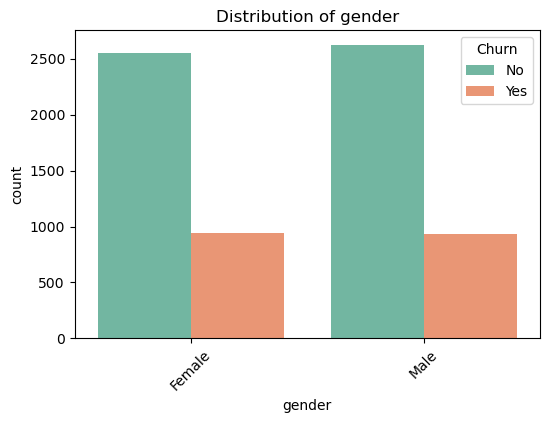

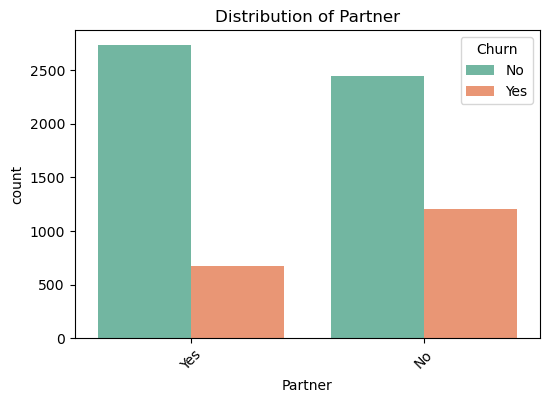

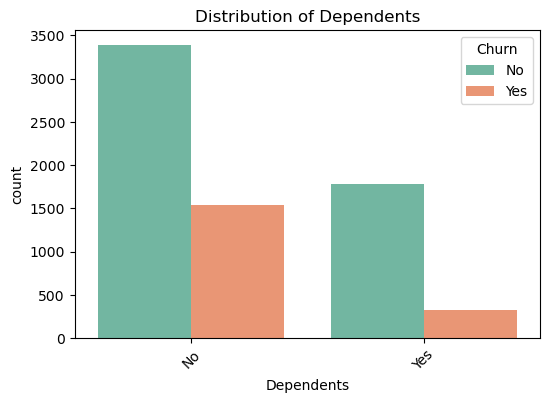

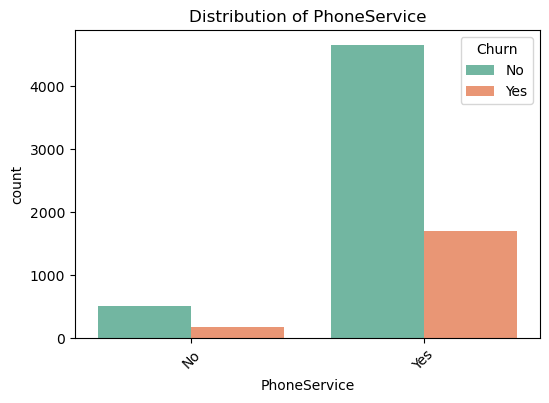

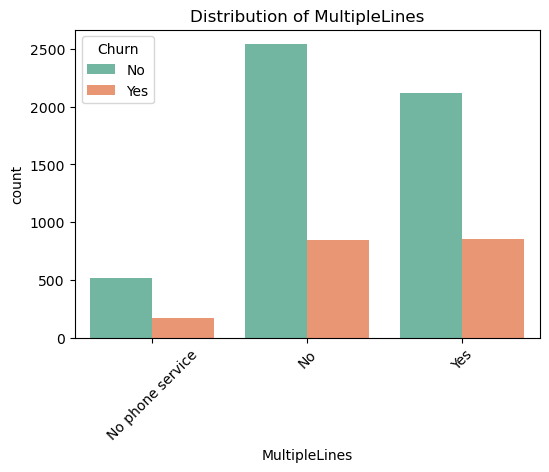

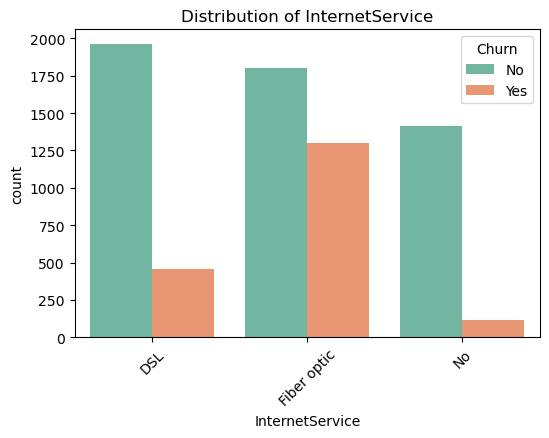

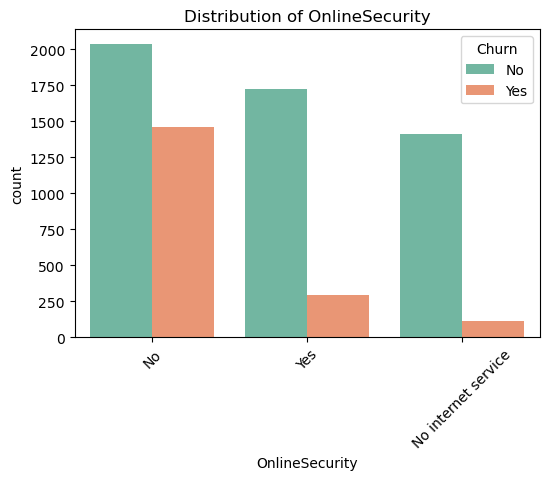

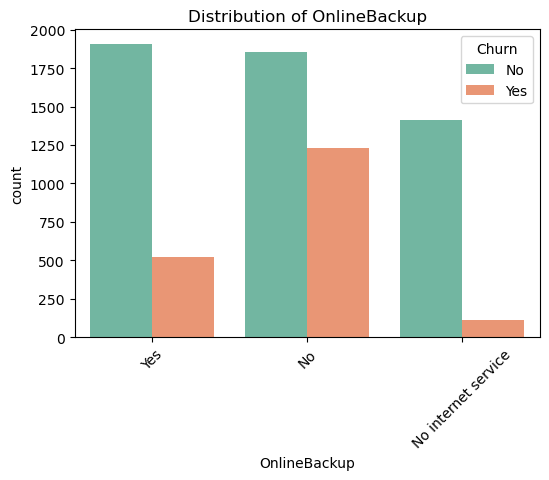

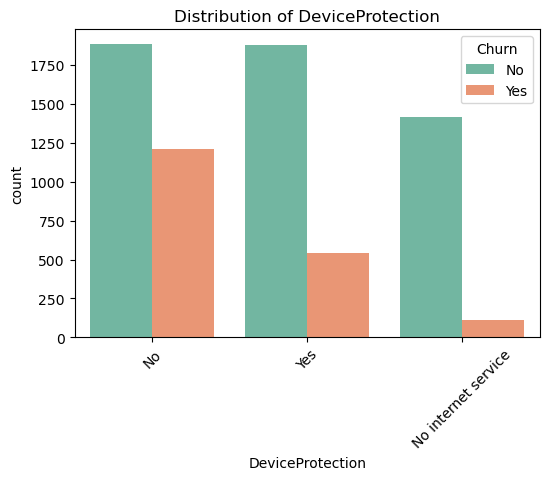

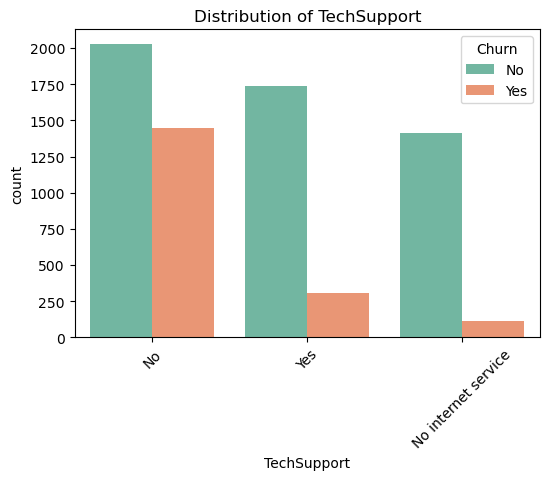

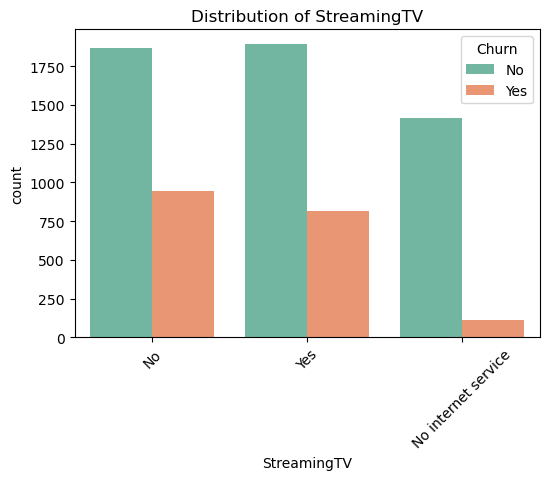

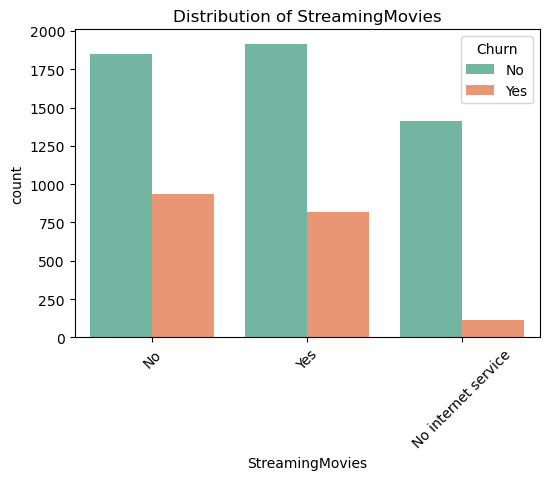

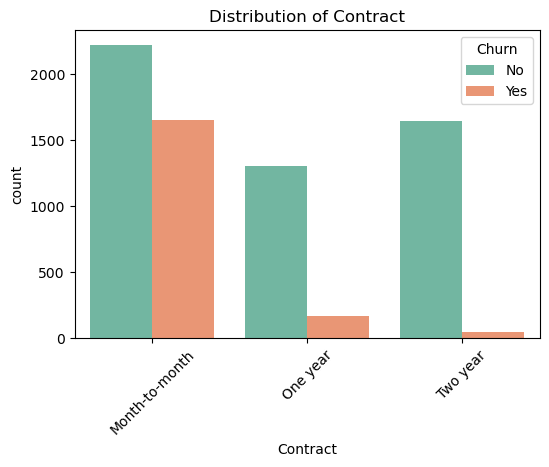

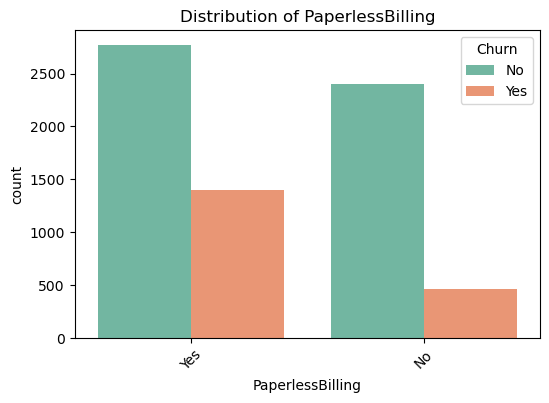

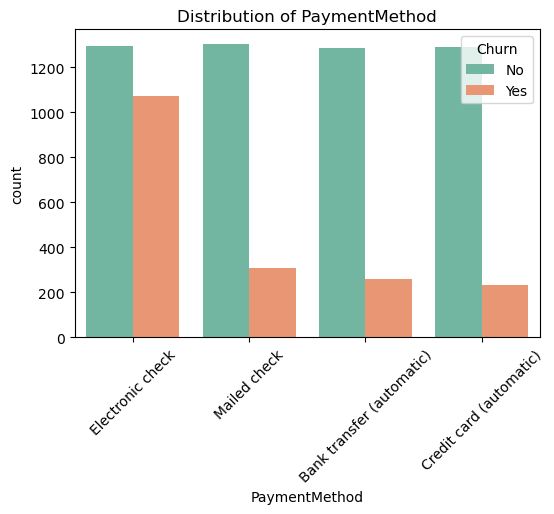

In [24]:
#Visualizing the distribution of categorical features with respect to the target variable 'Churn'
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=data, palette='Set2', hue='Churn')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

C:\Users\karan\AppData\Local\Temp\ipykernel_3660\892571933.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=churn_yes_total_charges, label='Churn: Yes', shade=True)
C:\Users\karan\AppData\Local\Temp\ipykernel_3660\892571933.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=churn_no_total_charges, label='Churn: No', shade=True)


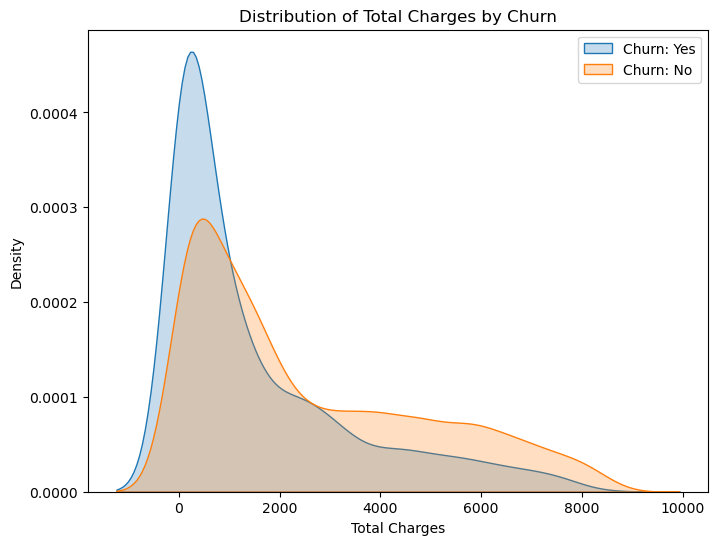

In [25]:
#Visualizing the distribution of numerical features with respect to the target variable 'Churn'
# For TotalCharges, we will use a KDE plot to visualize the distribution for both churned and non-churned customers
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
churn_yes_total_charges = data[data['Churn'] == 'Yes']['TotalCharges']
churn_no_total_charges = data[data['Churn'] == 'No']['TotalCharges']
plt.figure(figsize=(8, 6))
sns.kdeplot(x=churn_yes_total_charges, label='Churn: Yes', shade=True)
sns.kdeplot(x=churn_no_total_charges, label='Churn: No', shade=True)
plt.title('Distribution of Total Charges by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Density')
plt.legend()
plt.show()

C:\Users\karan\AppData\Local\Temp\ipykernel_3660\2992567500.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=churn_yes_monthly_charges, label='Churn: Yes', shade=True)
C:\Users\karan\AppData\Local\Temp\ipykernel_3660\2992567500.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=churn_no_monthly_charges, label='Churn: No', shade=True)


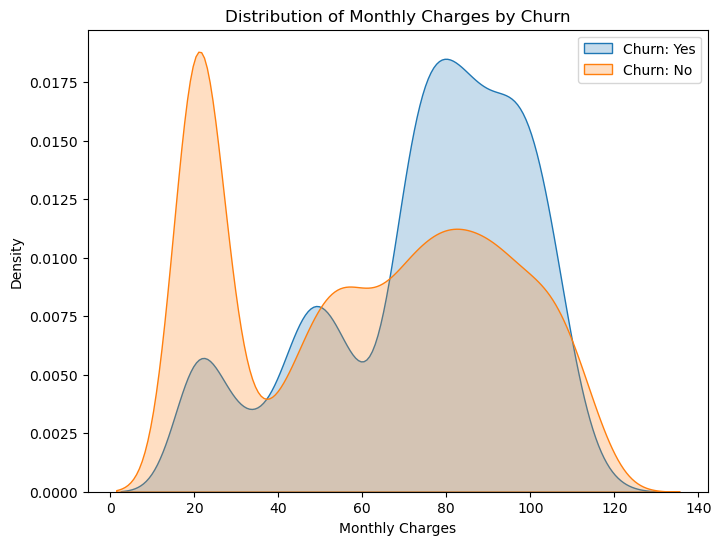

In [26]:
# For MonthlyCharges, we will also use a KDE plot to visualize the distribution for both churned and non-churned customers
churn_yes_monthly_charges = data[data['Churn'] == 'Yes']['MonthlyCharges']
churn_no_monthly_charges = data[data['Churn'] == 'No']['MonthlyCharges']
plt.figure(figsize=(8, 6))
sns.kdeplot(x=churn_yes_monthly_charges, label='Churn: Yes', shade=True)
sns.kdeplot(x=churn_no_monthly_charges, label='Churn: No', shade=True)
plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend()
plt.show()

C:\Users\karan\AppData\Local\Temp\ipykernel_3716\767258454.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=churn_yes_tenure, label='Churn: Yes', shade=True)
C:\Users\karan\AppData\Local\Temp\ipykernel_3716\767258454.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=churn_no_tenure, label='Churn: No', shade=True)


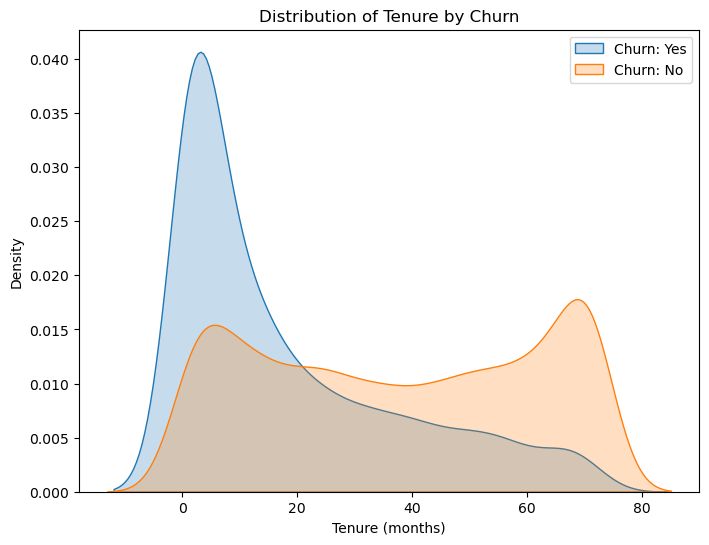

In [67]:
churn_yes_tenure = data[data['Churn'] == 'Yes']['tenure']
churn_no_tenure = data[data['Churn'] == 'No']['tenure']
plt.figure(figsize=(8, 6))
sns.kdeplot(x=churn_yes_tenure, label='Churn: Yes', shade=True)
sns.kdeplot(x=churn_no_tenure, label='Churn: No', shade=True)
plt.title('Distribution of Tenure by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.legend()
plt.show()

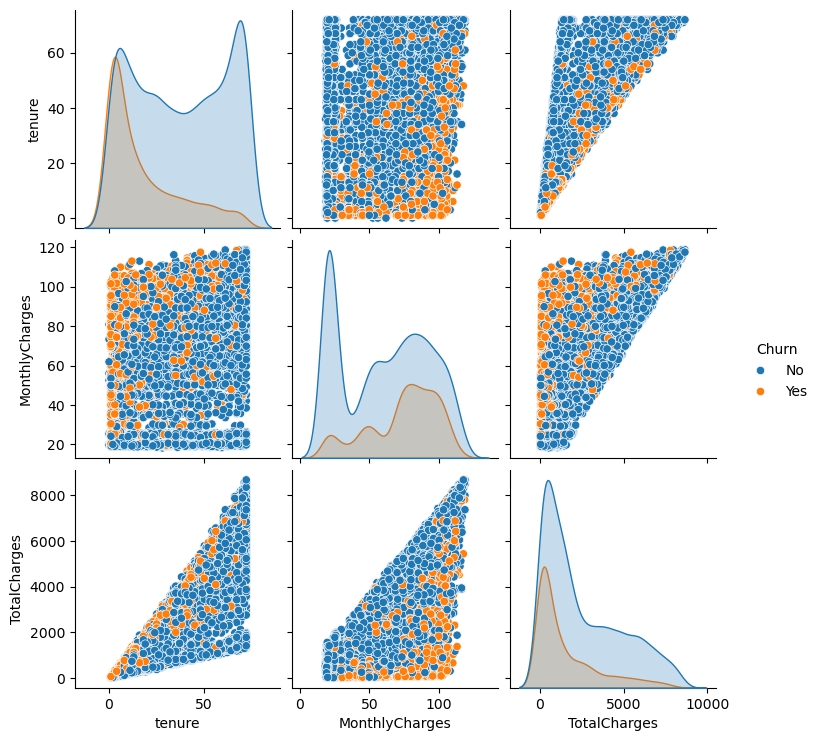

In [27]:
#Visualizing the pairwise relationships between numerical features with respect to the target variable 'Churn'
cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

sns.pairplot(
    data[cols],
    hue='Churn',
    diag_kind='kde'
)

plt.show()

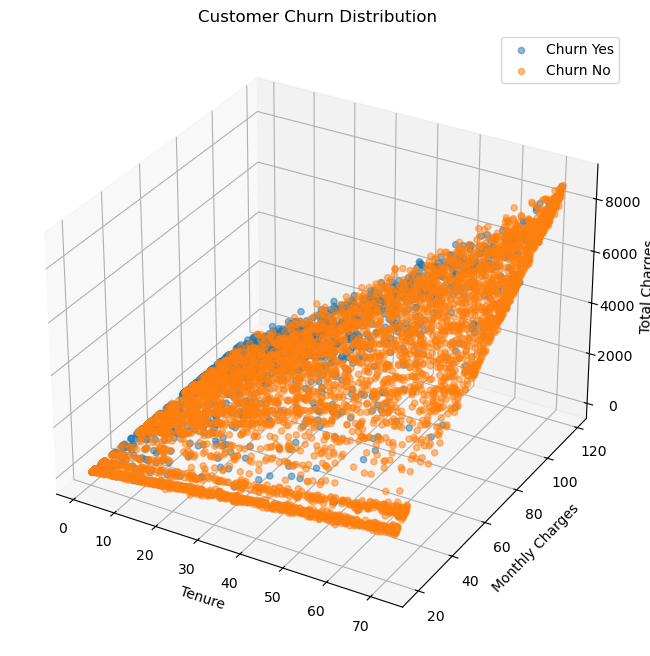

In [28]:
#Visualizing the 3D relationship between tenure, MonthlyCharges, and TotalCharges with respect to the target variable 'Churn'
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

churn_yes = data[data['Churn'] == 'Yes']
churn_no = data[data['Churn'] == 'No']

ax.scatter(
    churn_yes['tenure'],
    churn_yes['MonthlyCharges'],
    churn_yes['TotalCharges'],
    label='Churn Yes',
    alpha=0.5
)

ax.scatter(
    churn_no['tenure'],
    churn_no['MonthlyCharges'],
    churn_no['TotalCharges'],
    label='Churn No',
    alpha=0.5
)

ax.set_xlabel('Tenure')
ax.set_ylabel('Monthly Charges')
ax.set_zlabel('Total Charges')

plt.legend()
plt.title('Customer Churn Distribution')

plt.show()

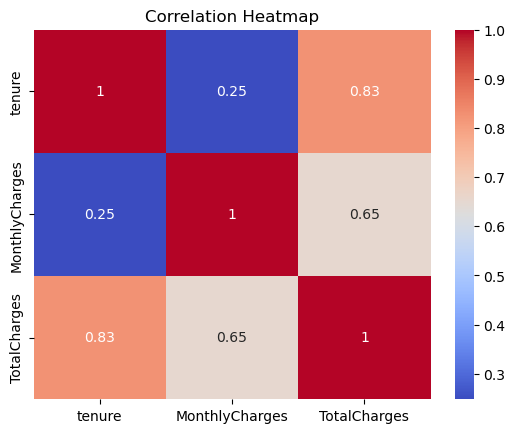

In [29]:
#Visualizing the correlation between numerical features using a heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

corr = data[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

C:\Users\karan\AppData\Local\Temp\ipykernel_3660\3932920292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2')


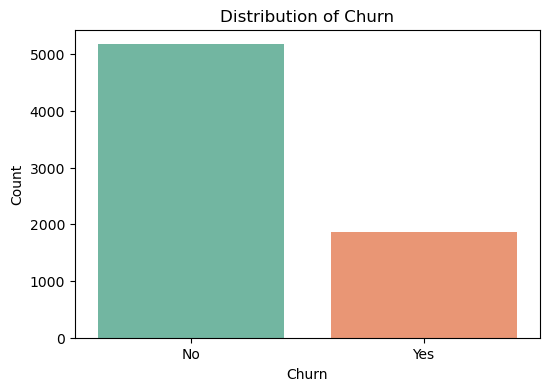

In [30]:
#Checking the balance of the target variable 'Churn'
churn_counts = data['Churn'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [76]:
data.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# Imputing missing values in TotalCharges with the product of MonthlyCharges and tenure, as TotalCharges is expected to be the total amount charged over the tenure period
data['TotalCharges'].fillna(data['MonthlyCharges']*data['tenure'], inplace=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_3660\2818359492.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['MonthlyCharges']*data['tenure'], inplace=True)


In [32]:
#Model Building and Evaluation, we will use several machine learning algorithms to predict customer churn and evaluate their performance using classification metrics such as accuracy, precision, recall, and F1-score.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [33]:
# Encoding categorical variables using LabelEncoder, as most of the categorical features are binary and can be easily encoded without losing information. For features
label_encoder = LabelEncoder()
data = data.apply(lambda col: label_encoder.fit_transform(col) if col.dtype == 'object' else col)
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
#Resampling the training data using SMOTE to address class imbalance in the target variable 'Churn', which can improve the performance of machine learning models by providing a more balanced dataset for training.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [36]:
# Training and evaluating multiple machine learning models to predict customer churn, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. We will evaluate the performance of each model using classification metrics such as accuracy, precision, recall, and F1-score.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("-" * 50)


c:\Users\karan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.78      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409

Confusion Matrix:
[[786 250]
 [ 82 291]]
Accuracy: 0.7644
--------------------------------------------------
Model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1036
           1       0.48      0.54      0.51       373

    accuracy                           0.72      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.72      0.73      1409

Confusion Matrix:
[[819 217]
 [172 201]]
Accuracy: 0.7239
--------------------------------------------------
Model: Random Forest
Classificatio

c:\Users\karan\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:00:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
#Taking the best recall model, which is Logistic Regression, and evaluating it further to understand its performance in more detail using SHAP values to interpret the model's predictions and identify which features are most influential in predicting customer churn.
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_resampled, y_train_resampled)
y_pred_logistic = logistic_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.78      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409



c:\Users\karan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


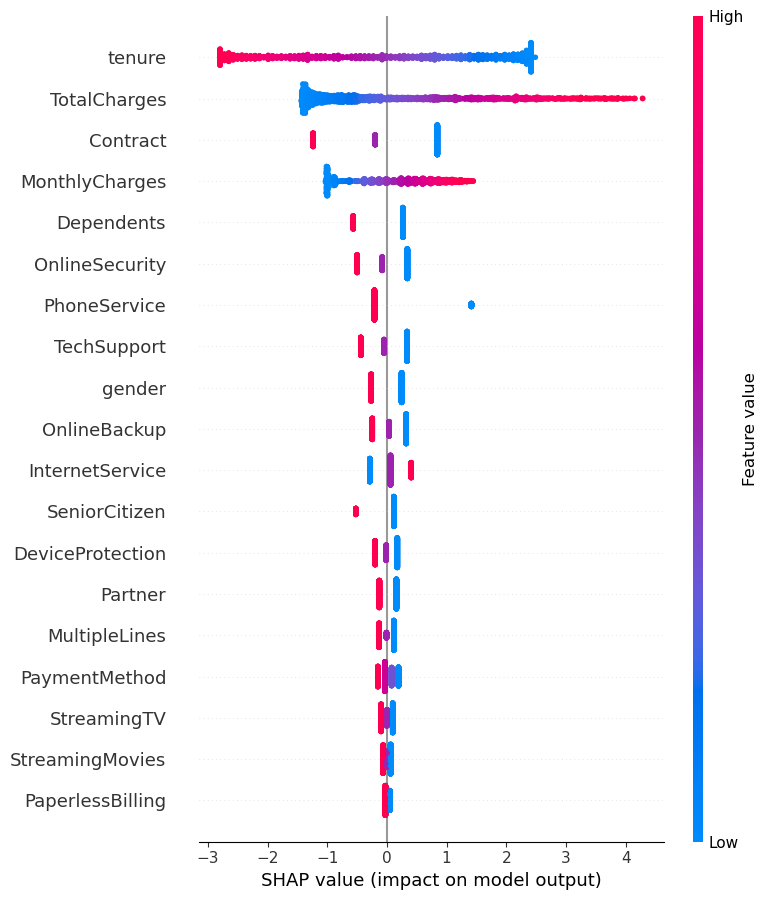

In [38]:
import shap

#Creating SHAP explainer for the logistic regression model
explainer = shap.Explainer(logistic_model, X_train)

#Calculating SHAP values for the test set
shap_values = explainer.shap_values(X_test)

#Summarizing the SHAP values to identify the most important features
shap.summary_plot(shap_values, X_test)